In [43]:
import pandas as pd
#for data handling, manipulation, augment
import matplotlib.pyplot as plt
#to visualize the data in charts, plots, diagrams/graphs

from sklearn.model_selection import train_test_split
#using this lib.  to select the function split dataset
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, r2_score

In [44]:
data = {
    "Age": [1,2,3,4,5,6,7,8,9,10],
    "Mileage": [10000,20000,30000,40000,50000,60000,70000,80000,90000,100000],
    "Price": [950000,975000,1000000,1111500,1200000,1250000,1275000,1300000,1325000,1350000]
}
df = pd.DataFrame(data)
print(df)

   Age  Mileage    Price
0    1    10000   950000
1    2    20000   975000
2    3    30000  1000000
3    4    40000  1111500
4    5    50000  1200000
5    6    60000  1250000
6    7    70000  1275000
7    8    80000  1300000
8    9    90000  1325000
9   10   100000  1350000


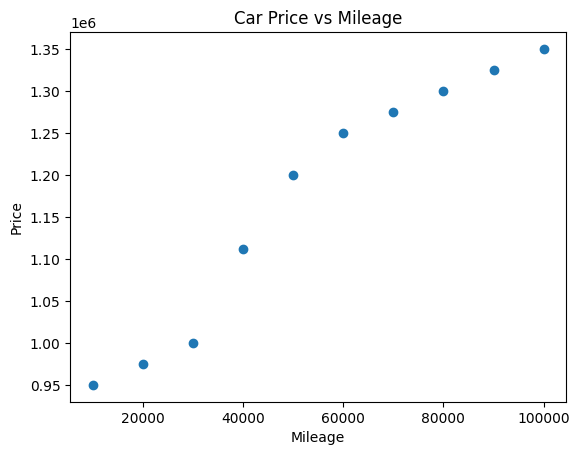

In [45]:
plt.scatter(df["Mileage"],df["Price"])
plt.title("Car Price vs Mileage")
plt.xlabel("Mileage")
plt.ylabel("Price")

plt.show()

In [46]:
X= df[["Mileage"]]
y= df["Price"]

In [47]:
X_train , X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    #testing on only 20% of the data
    random_state=42
    #generates reproducibility-database shuffles value in itself so the sequence isn't known, 42 is a constant value
)

In [48]:
print(X.head())

   Mileage
0    10000
1    20000
2    30000
3    40000
4    50000


In [49]:
print(X.dtypes)


Mileage    int64
dtype: object


In [50]:
print(y.head())

0     950000
1     975000
2    1000000
3    1111500
4    1200000
Name: Price, dtype: int64


In [51]:
X = pd.get_dummies(X, drop_first=True)

In [53]:
model = LinearRegression()

model.fit(X_train, y_train)
#fit is used to train the dataset

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[4.86]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Mileage']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9.121e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [54]:
prediction = model.predict(X_test)
print(prediction)

[1349750. 1009375.]


In [55]:
print("R2 Score: ", r2_score(y_test,prediction))

print("MAE : ", mean_absolute_error(y_test, prediction))

R2 Score:  0.970706887755102
MAE :  29562.5


In [56]:
print(X.columns)
print(model.n_features_in_)

Index(['Mileage'], dtype='str')
1


In [57]:
print(X.shape)
print(X.head())

(10, 1)
   Mileage
0    10000
1    20000
2    30000
3    40000
4    50000


In [58]:
new_car = [[45000]]

price = model.predict(new_car)

print("Predicted Price =", price[0])

Predicted Price = 1130937.5


c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


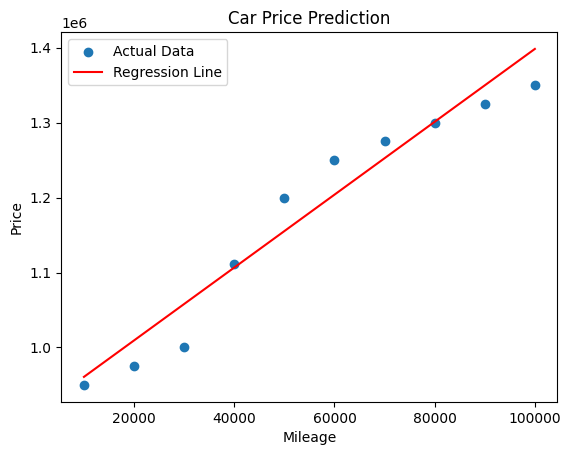

In [59]:
plt.scatter(df["Mileage"], df["Price"], label="Actual Data")
plt.plot(
    df["Mileage"],
    model.predict(df[["Mileage"]]),
    color = "red",
    label = "Regression Line"
)

plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Car Price Prediction")

plt.legend()
plt.show()